<h2 style = "text-align:center;">
M5 FP&A Sales Analysis
</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sympy as sp

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## File paths

The files are stored in the `Data` folder of the project.

In [2]:
calendar_file = r"C:\IDE\Projects\FPNA-Sales-Performance-Lab\Data\calendar.csv"
validation_file = r"C:\IDE\Projects\FPNA-Sales-Performance-Lab\Data\sales_train_validation.csv"
evaluation_file = r"C:\IDE\Projects\FPNA-Sales-Performance-Lab\Data\sales_train_evaluation.csv"
sample_submission_file = r"C:\IDE\Projects\FPNA-Sales-Performance-Lab\Data\sample_submission.csv"
sell_prices_file = r"C:\IDE\Projects\FPNA-Sales-Performance-Lab\Data\sell_prices.csv"

In [3]:
def read_sales_file(file_path):
    header = pd.read_csv(file_path, nrows=0).columns.tolist()
    daily_cols = [col for col in header if col.startswith("d_")]

    dtype_map = {
        "id": "category",
        "item_id": "category",
        "dept_id": "category",
        "cat_id": "category",
        "store_id": "category",
        "state_id": "category",
    }
    for col in daily_cols:
        dtype_map[col] = "int16"

    df = pd.read_csv(file_path, dtype=dtype_map)
    return df, daily_cols


def daily_units_table(df, daily_cols):
    table = df[daily_cols].sum().reset_index()
    table.columns = ["d", "units_sold"]
    return table


def simple_share_table(df, group_col, daily_cols):
    table = df.groupby(group_col)[daily_cols].sum().sum(axis=1).reset_index(name="units_sold")
    table = table.sort_values("units_sold", ascending=False).reset_index(drop=True)
    table["share_pct"] = np.round(table["units_sold"] / table["units_sold"].sum() * 100, 2)
    return table

## Load calendar and sample submission

In [4]:
calendar = pd.read_csv(calendar_file)
sample_submission = pd.read_csv(sample_submission_file)

calendar["date"] = pd.to_datetime(calendar["date"])
calendar["event_name_1"] = calendar["event_name_1"].fillna("No event")
calendar["event_name_2"] = calendar["event_name_2"].fillna("No event")
calendar["event_type_1"] = calendar["event_type_1"].fillna("No event")
calendar["event_type_2"] = calendar["event_type_2"].fillna("No event")

print("calendar shape:", calendar.shape)
print("sample submission shape:", sample_submission.shape)

calendar.head()

calendar shape: (1969, 14)
sample submission shape: (60980, 29)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,No event,No event,No event,No event,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,No event,No event,No event,No event,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,No event,No event,No event,No event,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,No event,No event,No event,No event,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,No event,No event,No event,No event,1,0,1


In [5]:
print("Missing values in calendar:")
print(calendar.isna().sum())

print("\nSample submission preview:")
sample_submission.head()

Missing values in calendar:
date            0
wm_yr_wk        0
weekday         0
wday            0
month           0
year            0
d               0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
dtype: int64

Sample submission preview:


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Validation sales file

This file is used for the main sales analysis.

In [6]:
sales_validation, validation_daily_cols = read_sales_file(validation_file)

validation_daily = daily_units_table(sales_validation, validation_daily_cols)
validation_daily = validation_daily.merge(calendar[["d", "date", "month", "year"]], on="d", how="left")
validation_daily["month_name"] = validation_daily["date"].dt.to_period("M").astype(str)

validation_total_units = int(validation_daily["units_sold"].sum())
validation_monthly = validation_daily.groupby("month_name", as_index=False)["units_sold"].sum()

validation_state = simple_share_table(sales_validation, "state_id", validation_daily_cols)
validation_store = simple_share_table(sales_validation, "store_id", validation_daily_cols)
validation_category = simple_share_table(sales_validation, "cat_id", validation_daily_cols)

sales_validation["total_units"] = sales_validation[validation_daily_cols].sum(axis=1)
validation_top_items = (
    sales_validation[["id", "item_id", "dept_id", "cat_id", "store_id", "state_id", "total_units"]]
    .sort_values("total_units", ascending=False)
    .head(10)
)

print("validation shape:", sales_validation.shape)
print("validation total units:", validation_total_units)

validation_daily.head()

C:\Users\rehan\AppData\Local\Temp\ipykernel_25656\1264694937.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(group_col)[daily_cols].sum().sum(axis=1).reset_index(name="units_sold")
C:\Users\rehan\AppData\Local\Temp\ipykernel_25656\1264694937.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(group_col)[daily_cols].sum().sum(axis=1).reset_index(name="units_sold")
C:\Users\rehan\AppData\Local\Temp\ipykernel_25656\1264694937.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

validation shape: (30490, 1920)
validation total units: 65695409


,d,units_sold,date,month,year,month_name
0,d_1,32631,2011-01-29,1,2011,2011-01
1,d_2,31749,2011-01-30,1,2011,2011-01
2,d_3,23783,2011-01-31,1,2011,2011-01
3,d_4,25412,2011-02-01,2,2011,2011-02
4,d_5,19146,2011-02-02,2,2011,2011-02


In [7]:
print("State summary:")
validation_state

State summary:


,state_id,units_sold,share_pct
0,CA,28675547,43.65
1,TX,18899006,28.77
2,WI,18120856,27.58


In [8]:
print("Store summary:")
validation_store

Store summary:


,store_id,units_sold,share_pct
0,CA_3,11188180,17.03
1,CA_1,7698216,11.72
2,TX_2,7214384,10.98
3,WI_2,6544012,9.96
4,WI_3,6427782,9.78
5,TX_3,6089330,9.27
6,CA_2,5685475,8.65
7,TX_1,5595292,8.52
8,WI_1,5149062,7.84
9,CA_4,4103676,6.25


In [9]:
print("Category summary:")
validation_category

Category summary:


,cat_id,units_sold,share_pct
0,FOODS,45089939,68.63
1,HOUSEHOLD,14480670,22.04
2,HOBBIES,6124800,9.32


In [10]:
print("Top 10 items:")
validation_top_items

Top 10 items:


,id,item_id,dept_id,cat_id,store_id,state_id,total_units
8412,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,250502
18055,FOODS_3_586_TX_2_validation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,192835
21104,FOODS_3_586_TX_3_validation,FOODS_3_586,FOODS_3,FOODS,TX_3,TX,150122
8908,FOODS_3_586_CA_3_validation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,134386
2314,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,127203
29755,FOODS_3_090_WI_3_validation,FOODS_3_090,FOODS_3,FOODS,WI_3,WI,121434
17559,FOODS_3_090_TX_2_validation,FOODS_3_090,FOODS_3,FOODS,TX_2,TX,119496
20608,FOODS_3_090_TX_3_validation,FOODS_3_090,FOODS_3,FOODS,TX_3,TX,114854
17721,FOODS_3_252_TX_2_validation,FOODS_3_252,FOODS_3,FOODS,TX_2,TX,114153
15006,FOODS_3_586_TX_1_validation,FOODS_3_586,FOODS_3,FOODS,TX_1,TX,112454


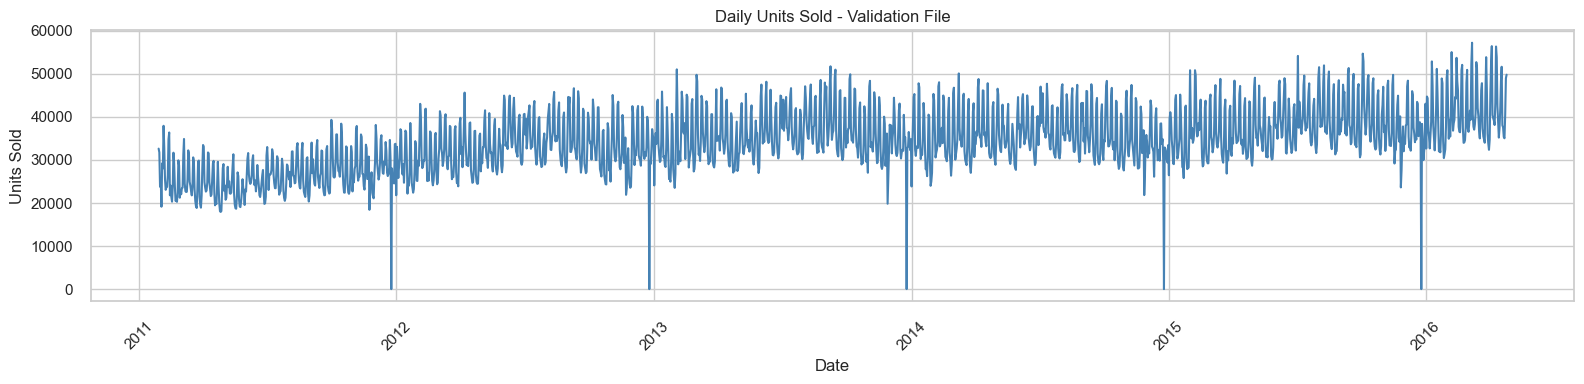

In [11]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.lineplot(data=validation_daily, x="date", y="units_sold", ax=ax, color="steelblue")
ax.set_title("Daily Units Sold - Validation File")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

px.line(
    validation_daily,
    x="date",
    y="units_sold",
    title="Interactive Daily Units Sold - Validation File",
).show()

## Evaluation sales file

This file has the same structure and helps us compare the longer horizon.

In [12]:
sales_evaluation, evaluation_daily_cols = read_sales_file(evaluation_file)

evaluation_daily = daily_units_table(sales_evaluation, evaluation_daily_cols)
evaluation_daily = evaluation_daily.merge(calendar[["d", "date", "month", "year"]], on="d", how="left")
evaluation_daily["month_name"] = evaluation_daily["date"].dt.to_period("M").astype(str)

evaluation_total_units = int(evaluation_daily["units_sold"].sum())
evaluation_monthly = evaluation_daily.groupby("month_name", as_index=False)["units_sold"].sum()

print("evaluation shape:", sales_evaluation.shape)
print("evaluation total units:", evaluation_total_units)

evaluation_daily.head()

evaluation shape: (30490, 1947)
evaluation total units: 66927173


,d,units_sold,date,month,year,month_name
0,d_1,32631,2011-01-29,1,2011,2011-01
1,d_2,31749,2011-01-30,1,2011,2011-01
2,d_3,23783,2011-01-31,1,2011,2011-01
3,d_4,25412,2011-02-01,2,2011,2011-02
4,d_5,19146,2011-02-02,2,2011,2011-02


In [13]:
comparison = pd.DataFrame(
    {
        "file": ["validation", "evaluation"],
        "total_units": [validation_total_units, evaluation_total_units],
    }
)

print("Validation vs evaluation:")
comparison

Validation vs evaluation:


,file,total_units
0,validation,65695409
1,evaluation,66927173


C:\Users\rehan\AppData\Local\Temp\ipykernel_25656\2431766205.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="file", y="total_units", ax=ax, palette="Blues_r")


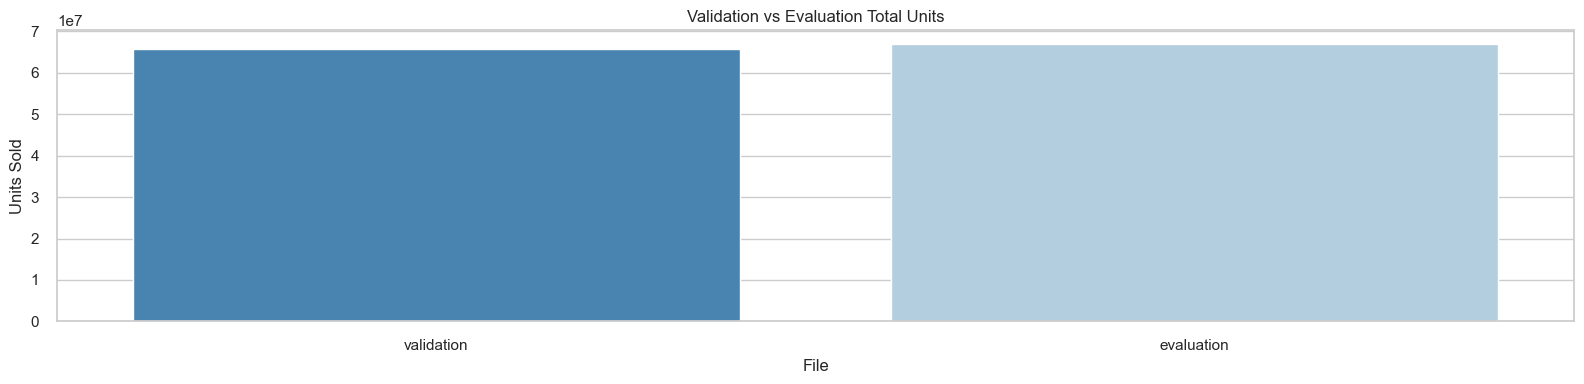

In [14]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.barplot(data=comparison, x="file", y="total_units", ax=ax, palette="Blues_r")
ax.set_title("Validation vs Evaluation Total Units")
ax.set_xlabel("File")
ax.set_ylabel("Units Sold")
plt.tight_layout()
plt.show()

px.bar(
    comparison,
    x = comparison["file"],
    y = comparison["total_units"],
    title = "Validation vs Evaluation Total Units",
    color = comparison["file"],
    color_continuous_scale = "Blues_r"
)

## Sell prices file

In [15]:
sell_prices = pd.read_csv(
    sell_prices_file,
    dtype={
        "store_id": "category",
        "item_id": "category",
        "wm_yr_wk": "int32",
        "sell_price": "float32",
    },
)

price_summary = sell_prices[["sell_price"]].describe()
price_by_store = sell_prices.groupby("store_id")["sell_price"].mean().reset_index()
price_by_week = sell_prices.groupby("wm_yr_wk")["sell_price"].mean().reset_index()

print("sell_prices shape:", sell_prices.shape)
price_summary

C:\Users\rehan\AppData\Local\Temp\ipykernel_25656\2523672437.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_store = sell_prices.groupby("store_id")["sell_price"].mean().reset_index()


sell_prices shape: (6841121, 4)


,sell_price
count,6.841121e+06
mean,4.410953e+00
std,3.408814e+00
min,1.000000e-02
25%,2.180000e+00
50%,3.470000e+00
75%,5.840000e+00
max,1.073200e+02


In [16]:
print("Average sell price by store:")
price_by_store

Average sell price by store:


,store_id,sell_price
0,CA_1,4.414233
1,CA_2,4.445500
2,CA_3,4.388229
3,CA_4,4.421580
4,TX_1,4.374569
5,TX_2,4.366766
6,TX_3,4.387365
7,WI_1,4.457712
8,WI_2,4.441717
9,WI_3,4.418117


C:\Users\rehan\AppData\Local\Temp\ipykernel_25656\3996182883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_by_store, x="store_id", y="sell_price", ax=ax, palette="viridis")


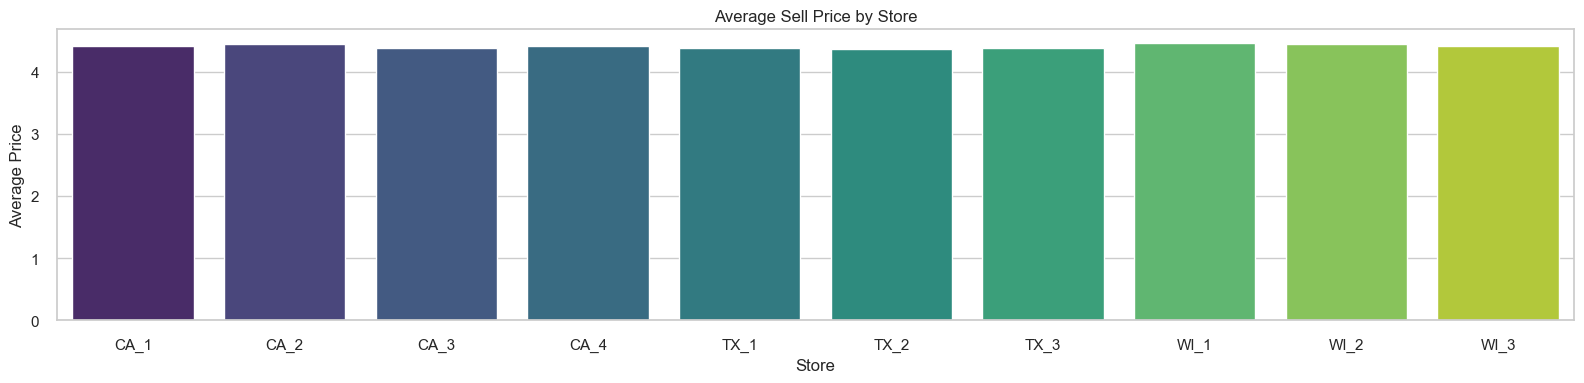

In [17]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.barplot(data=price_by_store, x="store_id", y="sell_price", ax=ax, palette="viridis")
ax.set_title("Average Sell Price by Store")
ax.set_xlabel("Store")
ax.set_ylabel("Average Price")
plt.tight_layout()
plt.show()

px.bar(
    price_by_store,
    x = price_by_store["store_id"],
    y = price_by_store["sell_price"],
    title = "Interactive Average Sell Price by Store",
    color = price_by_store["store_id"],
    color_continuous_scale = "Viridis"
).show()

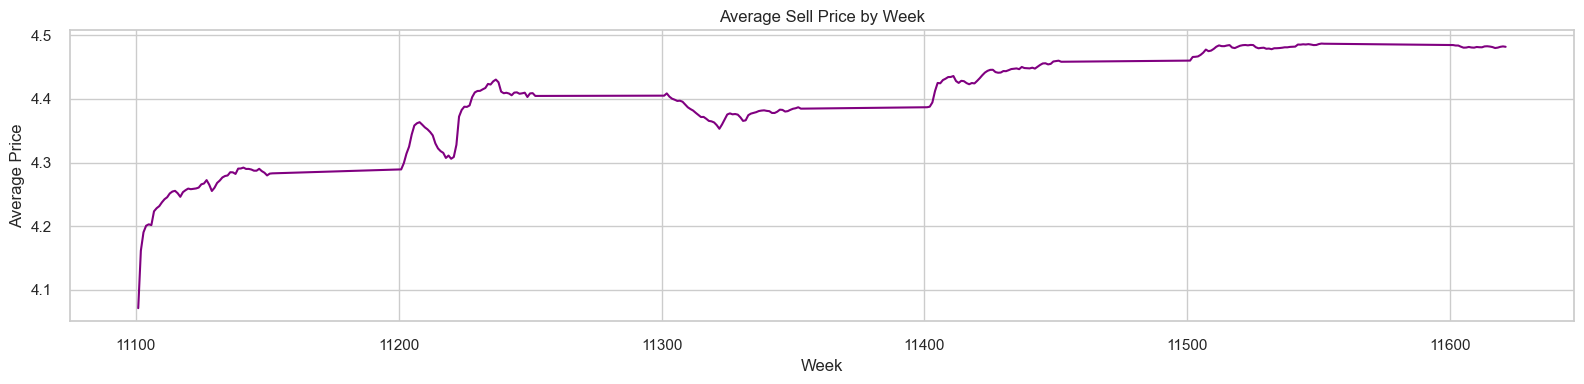

In [18]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.lineplot(data=price_by_week, x="wm_yr_wk", y="sell_price", ax=ax, color="purple")
ax.set_title("Average Sell Price by Week")
ax.set_xlabel("Week")
ax.set_ylabel("Average Price")
plt.tight_layout()
plt.show()

px.line(
    price_by_week,
    x="wm_yr_wk",
    y="sell_price",
    title="Interactive Average Sell Price by Week",
).show()

## Sympy FP&A formula

A very small formula example:

`profit = revenue - cogs - opex`

In [19]:
revenue, cogs, opex = sp.symbols("revenue cogs opex")
profit = sp.symbols("profit")

formula = sp.Eq(profit, revenue - cogs - opex)
break_even_revenue = sp.solve(formula, revenue)[0]

print("Profit formula:")
print(formula)
print("\nBreak-even revenue:")
print(break_even_revenue)


Profit formula:
Eq(profit, -cogs - opex + revenue)

Break-even revenue:
cogs + opex + profit


## Main takeaways

- The validation file shows the main sales pattern.
- The evaluation file lets us compare a longer horizon.
- The calendar file helps us understand dates and seasonality.
- The sell prices file helps us study pricing.
- The sample submission file shows the Kaggle output format.
- The simple FP&A formula connects the analysis to profit thinking.